In [5]:
import os
import tarfile
import urllib.request
#tarlib to extract csv file from .tgz and urllib to parse through urls basically no need to downlaod data directly from url get it

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
#where the dataset will be saved in my device
HOUSING_PATH = os.path.join("datasets","housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def load_housing_data():
    #make the housing path folders in my subfolder if not exist yet
    os.makedirs(HOUSING_PATH, exist_ok=True)  
    #path to tgz file which contains csv
    tgz_path = os.path.join(HOUSING_PATH , "housing.tgz")
    #retrieve file from given url and save in target path(tgz_path)
    urllib.request.urlretrieve(HOUSING_URL, tgz_path)
    #extraction
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=HOUSING_PATH)
    housing_tgz.close()

In [7]:
load_housing_data()

In [13]:
import pandas as sd
#make pandas dataframe of the data
def get_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(HOUSING_PATH , "housing.csv")
    return sd.read_csv(csv_path)

In [ ]:
housing = get_data()
housing.head()

# we have 9 features and 1 target variable, each row is a district

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [20]:
housing['ocean_proximity'].value_counts()
# see the number of categories in ocean_proximity and their counts

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

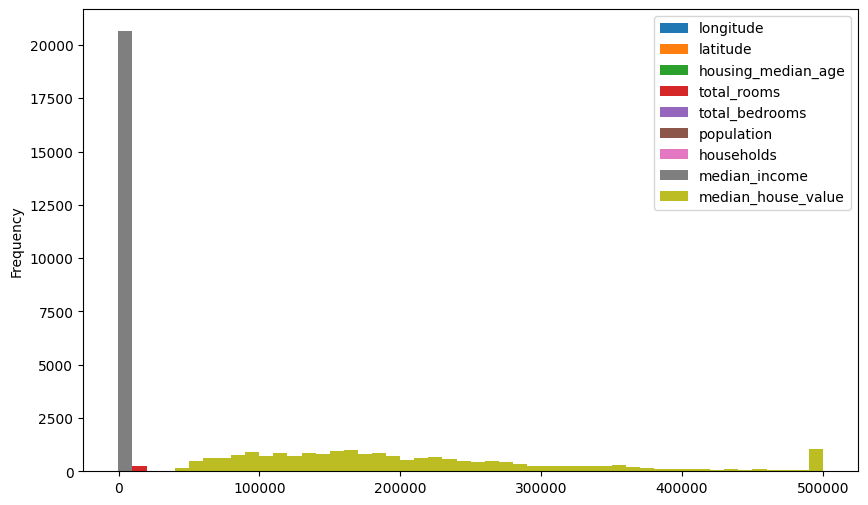

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.plot(kind="hist",bins=50, figsize=(10,6))

In [23]:
import numpy as np
#def split_train_test(data, test_ratio):
    # shuffle the indices of the rows in the dataset
    #shuffled_indices = np.random.permutation(len(data))
    #test_set_size = int(len(data) * test_ratio)
    #shuffled_test_indices = shuffled_indices[:test_set_size]
    #shuffled_train_indices = shuffled_indices[test_set_size:] this function creates a new training and test set each time we run causing data leakage hence we use sklearn's train_test_split function which uses a random state to create the same training and test set each time we run the code

In [24]:
# if we just randomly split up, we might end up with a training set that contains mostly low income districts and a test set that contains mostly high income districts, which would not be good for training our model. To avoid this problem, we can use stratified sampling based on the income category. This way, we ensure that both the training and test sets have a similar distribution of income categories, which helps our model generalize better to unseen data.
# for this we will use sklearn's StratifiedShuffleSplit class which is a cross-validator that provides train/test indices to split data into train/test sets. It is a variation of KFold that returns stratified folds, which are made by preserving the percentage of samples for each class. In our case, we will use it to split the data based on the income category.

#first we split up income category
housing['income_cat']=sd.cut(housing['median_income'], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])

from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
# n_splits=1: You only want to split the data once (generate one pair of train/test sets).
for train_index, test_index in split.split(housing, housing['income_cat']):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]
#upack the 2 values returned by split.split() into train_index and test_index, which are the indices of the training and test sets respectively. Then we use these indices to create the stratified training and test sets by selecting the corresponding rows from the original housing DataFrame using .loc[].


In [27]:
strat_test_set['income_cat'].value_counts() / len(strat_test_set)
housing['income_cat'].value_counts() / len(housing)
# see the distribution of income categories in the test set to verify that it is similar to the distribution in the original dataset. This should show that the proportions of each income category in the test set are similar to those in the original dataset, confirming that the stratified sampling was successful.

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [29]:
for set_ in (strat_train_set, strat_test_set):
 set_.drop("income_cat", axis=1, inplace=True)


<Axes: xlabel='longitude', ylabel='latitude'>

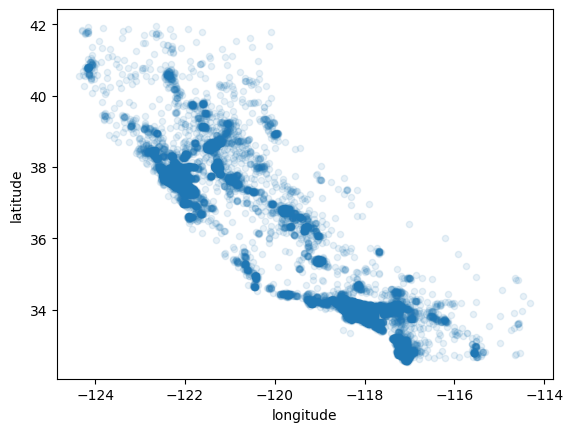

In [31]:
play_set = strat_train_set.copy()
play_set.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
# plot the districts on a scatter plot to visualize their geographical distribution. The longitude and latitude are used as the x and y coordinates, respectively. The alpha parameter is set to 0.1 to make the points semi-transparent, which helps to visualize areas with a high density of districts. This plot can help us understand the geographical distribution of the housing data and identify any patterns or clusters that may exist.

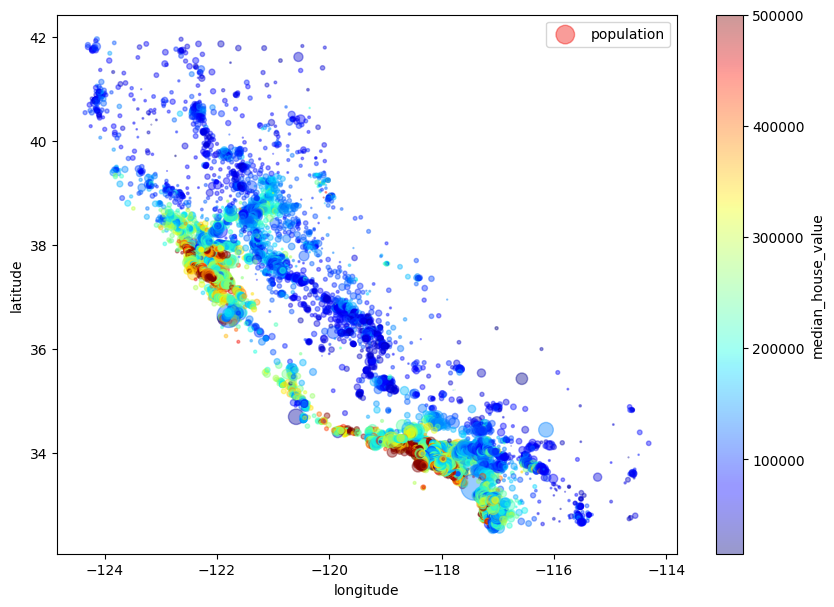

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
 s=housing["population"]/100, label="population", figsize=(10,7),
 c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
# s is the size of the points, which is set to be proportional to the population of the district (divided by 100 to make it more manageable). The color of the points is determined by the median house value, using a colormap called "jet". The colorbar=True argument adds a colorbar to the plot to show the mapping of colors to median house values. This plot allows us to visualize the relationship between location, population, and median house value in the dataset.
# size of the points is proportional to the population, and the color represents the median house value. This can help us identify areas with high population density and high or low house values, which may indicate patterns or trends in the housing market.
# we can create correlation matrix to see how the features are correlated with each other and with the target variable (median_house_value). This can help us identify which features are most important for predicting house values and which ones may be redundant or less useful for our model.
plt.legend()


In [34]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64